In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [2]:
df = pd.read_csv("../data/raw/dat-ab-usos-2026.csv",encoding="latin1")

In [3]:
df.head()

,DIA_TRANSPORTE,NOMBRE_EMPRESA,LINEA,AMBA,TIPO_TRANSPORTE,JURISDICCION,PROVINCIA,MUNICIPIO,CANTIDAD,DATO_PRELIMINAR
0,2026-01-01,MUNICIPALIDAD DE MERCEDES PROVINCIA DE BUENOS ...,1,SI,COLECTIVO,MUNICIPAL,BUENOS AIRES,MERCEDES,138,NO
1,2026-01-01,MUNICIPALIDAD DE MERCEDES PROVINCIA DE BUENOS ...,2B,SI,COLECTIVO,MUNICIPAL,BUENOS AIRES,MERCEDES,69,NO
2,2026-01-01,EMPRESA BATAN S.A.,BS_AS_LINEA 715M,NO,COLECTIVO,MUNICIPAL,BUENOS AIRES,GENERAL PUEYRREDON,1572,NO
3,2026-01-01,EMPRESA BATAN S.A.,BS_AS_LINEA 720M,NO,COLECTIVO,MUNICIPAL,BUENOS AIRES,GENERAL PUEYRREDON,475,NO
4,2026-01-01,COMPAÃIAÂ DE TRANSPORTE VECINAL S.A.,BS_AS_LINEA_326,SI,COLECTIVO,PROVINCIAL,BUENOS AIRES,SN,97,NO


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 149339 entries, 0 to 149338
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype
---  ------           --------------   -----
 0   DIA_TRANSPORTE   149339 non-null  str  
 1   NOMBRE_EMPRESA   149339 non-null  str  
 2   LINEA            149339 non-null  str  
 3   AMBA             149339 non-null  str  
 4   TIPO_TRANSPORTE  149339 non-null  str  
 5   JURISDICCION     148639 non-null  str  
 6   PROVINCIA        148639 non-null  str  
 7   MUNICIPIO        148639 non-null  str  
 8   CANTIDAD         149339 non-null  int64
 9   DATO_PRELIMINAR  149339 non-null  str  
dtypes: int64(1), str(9)
memory usage: 11.4 MB


In [5]:
df.columns

Index(['DIA_TRANSPORTE', 'NOMBRE_EMPRESA', 'LINEA', 'AMBA', 'TIPO_TRANSPORTE',
       'JURISDICCION', 'PROVINCIA', 'MUNICIPIO', 'CANTIDAD',
       'DATO_PRELIMINAR'],
      dtype='str')

El dataset contiene 149.339 registros y 10 variables relacionadas con el uso del sistema SUBE.

La variable CANTIDAD representa el número de transacciones y se encuentra en formato numérico, lo cual facilita el análisis.

La columna DIA_TRANSPORTE está en formato texto y deberá convertirse a tipo fecha para permitir análisis temporales.

Se detectan valores nulos en las variables JURISDICCION, PROVINCIA y MUNICIPIO, posiblemente asociados a ciertos tipos de transporte como subte.

In [6]:
df['DIA_TRANSPORTE'] = pd.to_datetime(df['DIA_TRANSPORTE'])
df['DIA_TRANSPORTE'].dtype

dtype('<M8[us]')

In [7]:
df_viajes_diarios = df.groupby('DIA_TRANSPORTE', as_index=False)['CANTIDAD'].sum()
df_viajes_diarios.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   DIA_TRANSPORTE  100 non-null    datetime64[us]
 1   CANTIDAD        100 non-null    int64         
dtypes: datetime64[us](1), int64(1)
memory usage: 1.7 KB


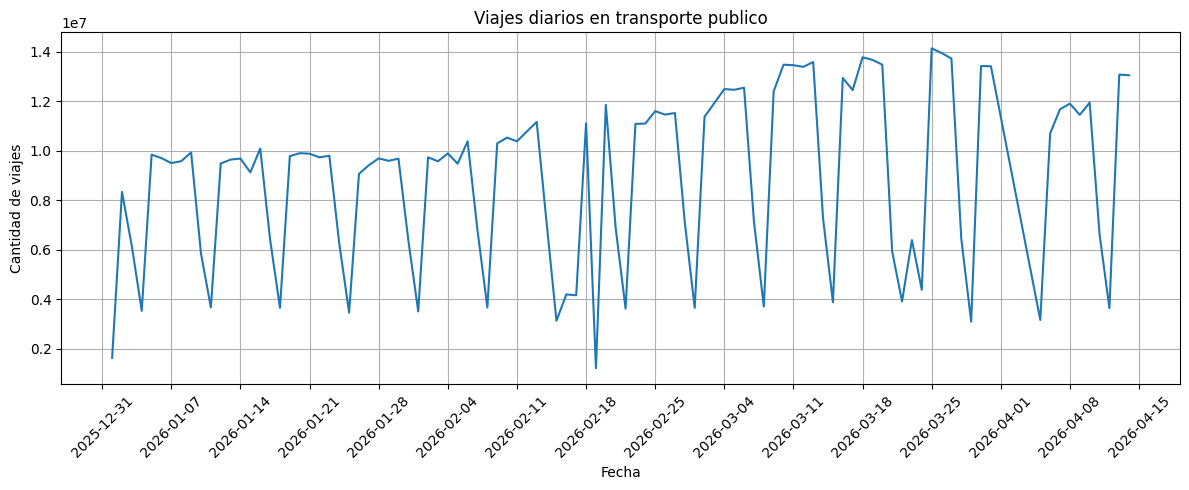

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df_viajes_diarios['DIA_TRANSPORTE'], df_viajes_diarios['CANTIDAD'])
ax.set_title('Viajes diarios en transporte publico')
ax.set_xlabel('Fecha')
ax.set_ylabel('Cantidad de viajes')
ax.xaxis.set_major_locator(mdates.DayLocator(interval=7))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()

Pareciera verse que en los días de semana hay más de 10 millones transacciones, mientras que en fines de semana estas bajan a 4 millones. 

Además, pareciera que a medida que avanza el año, se realizan más transacciones en los días de semana.

Por último, se notan períodos que rompen con el patrón semanal, como en la semana del 16/02/26, 

Exploremos más esta información.

In [9]:
dias_semana = {
    0: 'lunes',
    1: 'martes',
    2: 'miercoles',
    3: 'jueves',
    4: 'viernes',
    5: 'sabado',
    6: 'domingo'
}

df_viajes_diarios['dia'] = df_viajes_diarios['DIA_TRANSPORTE'].dt.dayofweek.map(dias_semana)
df_viajes_diarios.head()

,DIA_TRANSPORTE,CANTIDAD,dia
0,2026-01-01,1621473,jueves
1,2026-01-02,8332677,viernes
2,2026-01-03,6126432,sabado
3,2026-01-04,3524089,domingo
4,2026-01-05,9836834,lunes


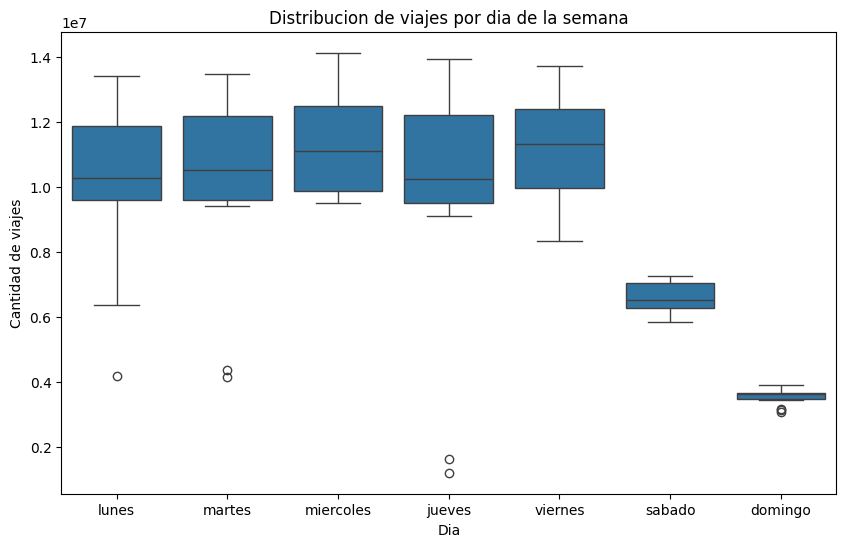

In [10]:
orden_dias = ['lunes', 'martes', 'miercoles', 'jueves', 'viernes', 'sabado', 'domingo']

plt.figure(figsize=(10, 6))
sns.boxplot(x='dia', y='CANTIDAD', data=df_viajes_diarios, order=orden_dias)

plt.title('Distribucion de viajes por dia de la semana')
plt.xlabel('Dia')
plt.ylabel('Cantidad de viajes')
#plt.xticks(rotation=45)
plt.show()


Se puede ver entonces que en los días de semana se suelen realizar entre 8 y 14 millones de transacciones, mientras que los sábados se realizan entre 6 y 8 millones, y los domingos alrededor de 4 millones.

Cabe destacar también que hay mayor variación los días lunes, y que en los domingos hay muy poca.

Además, aparecen algunos datos atípicos en los días lunes, martes y especialmente jueves.